In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sys.path.append('../src')
from utils import mean_imputation, create_missing_data
from gmm_missing import GMMMissing

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=4, suppress=True)

In [2]:
data = pd.read_csv('../data/CC GENERAL.csv')
data.drop('CUST_ID', axis=1, inplace=True)
data.head(2)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.4,0.0,95.4,0.000000,0.166667,0.0,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.0,0.0,0.0,6442.945483,0.000000,0.0,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12


In [3]:
#random create missing data 30% missing
X_true, X_incomplete, mask_missing = create_missing_data(data,0.3)
print("Số lượng giá trị thiếu sau khi tạo dữ liệu thiếu:\n", np.isnan(X_incomplete).sum())

Số lượng giá trị thiếu sau khi tạo dữ liệu thiếu:
 45789


In [4]:
# Nội suy thô bằng Mean
X_initial = mean_imputation(X_incomplete)
scaler = StandardScaler()
X_initial = scaler.fit_transform(X_initial)

gmm = GMMMissing(n_components=3,max_iter=1, tol=1e-4, random_state=42)
gmm._initialize_parameters(X_initial)

In [5]:
print("Trung bình các cụm (mu) khởi tạo từ K-Means:\n", gmm.mu_)


Trung bình các cụm (mu) khởi tạo từ K-Means:
 [[ 0.2174  0.3834  1.2344  1.1009  1.044  -0.2085  1.0113  1.4685  0.7409
  -0.3374 -0.2204  1.3804  0.7929  0.6695  0.1074  0.4273  0.2384]
 [ 1.072   0.3113 -0.2557 -0.1892 -0.2436  1.2887 -0.5736 -0.2441 -0.4898
   1.5244  1.2457 -0.3083  0.5343  0.4167  0.3375 -0.3458 -0.1143]
 [-0.2894 -0.1497 -0.1947 -0.1825 -0.1584 -0.2516 -0.0763 -0.2453 -0.04
  -0.279  -0.2393 -0.2126 -0.2846 -0.2324 -0.0991 -0.0086 -0.0228]]


In [6]:
log_likelihood, gamma = gmm._e_step(X_initial)
print("Xác suất hậu nghiệm gamma (5 mẫu đầu tiên):\n", gamma[:5])

Xác suất hậu nghiệm gamma (5 mẫu đầu tiên):
 [[0.     0.0001 0.9999]
 [0.     0.0789 0.9211]
 [0.9919 0.     0.0081]
 [0.     0.     1.    ]
 [0.     0.0006 0.9994]]


In [7]:
gmm._m_step_params(X_initial, gamma)
print("Tâm cụm sau 1 vòng M-Step:\n", gmm.mu_)

Tâm cụm sau 1 vòng M-Step:
 [[ 0.2238  0.3743  1.2313  1.0976  1.0584 -0.196   0.9348  1.3822  0.6196
  -0.3341 -0.2232  1.3436  0.7328  0.6779  0.1354  0.4328  0.269 ]
 [ 1.0084  0.2803 -0.2476 -0.1877 -0.2293  1.196  -0.4877 -0.2241 -0.4228
   1.3714  1.1719 -0.2866  0.494   0.4261  0.4556 -0.3364 -0.1261]
 [-0.2948 -0.1467 -0.1944 -0.1814 -0.163  -0.2539 -0.0737 -0.2315 -0.0244
  -0.2685 -0.2424 -0.2081 -0.2736 -0.2455 -0.1403 -0.0069 -0.0247]]


In [8]:
# --- TRỰC QUAN HÓA LOGIC PHƯƠNG TRÌNH 14 TRONG gmm_missing.py ---
# Lấy Sample số 0 làm ví dụ
sample_index = 0

# Tách mask cho sample 0
m_part = mask_missing[sample_index]     # Các chiều bị missing (True)
o_part = ~mask_missing[sample_index]    # Các chiều có dữ liệu (False)

if np.any(m_part):
    print(f"Sample {sample_index} gốc có NaNs: {X_incomplete[sample_index]}")
    x_j_o = X_initial[sample_index, o_part]
    
    # Tổng tích lũy ma trận theo k (k=3 cụm)
    sum_L_mm = np.zeros((np.sum(m_part), np.sum(m_part)))
    sum_term2 = np.zeros(np.sum(m_part))
    
    for k in range(gmm.n_components):
        gamma_jk = gamma[sample_index, k]
        Lambda_k = np.linalg.inv(gmm.covariances_[k])
        
        # Trích xuất L_mm và L_mo (Phương trình 13)
        L_mm = Lambda_k[np.ix_(m_part, m_part)]
        L_mo = Lambda_k[np.ix_(m_part, o_part)]
        
        mu_m = gmm.mu_[k, m_part]
        mu_o = gmm.mu_[k, o_part]
        
        # Phương trình 14 tích lũy
        sum_L_mm += gamma_jk * L_mm
        term2 = L_mm @ mu_m - L_mo @ (x_j_o - mu_o)
        sum_term2 += gamma_jk * term2
        
    # Cập nhật kết quả cuối cùng
    x_j_m_updated = np.linalg.inv(sum_L_mm) @ sum_term2
    
    print(f"Dữ liệu nội suy thô (Mean): {X_initial[sample_index]}")
    print(f"Tọa độ bị thiếu NAY ĐÃ ĐƯỢC KÉO về mốc mới: {x_j_m_updated}")

Sample 0 gốc có NaNs: [  40.9007    0.8182   95.4       0.           nan       nan       nan
    0.        0.0833    0.           nan    2.     1000.           nan
       nan       nan   12.    ]
Dữ liệu nội suy thô (Mean): [-0.8805 -0.2995 -0.5061 -0.4502  0.      0.     -0.     -0.8109 -0.8443
 -0.8103  0.     -0.6151 -1.146   0.     -0.      0.      0.429 ]
Tọa độ bị thiếu NAY ĐÃ ĐƯỢC KÉO về mốc mới: [-0.3765 -0.3723 -0.7398 -0.3829 -0.4166 -0.2393  0.1273]


Thuật toán hội tụ sau 199 vòng lặp.


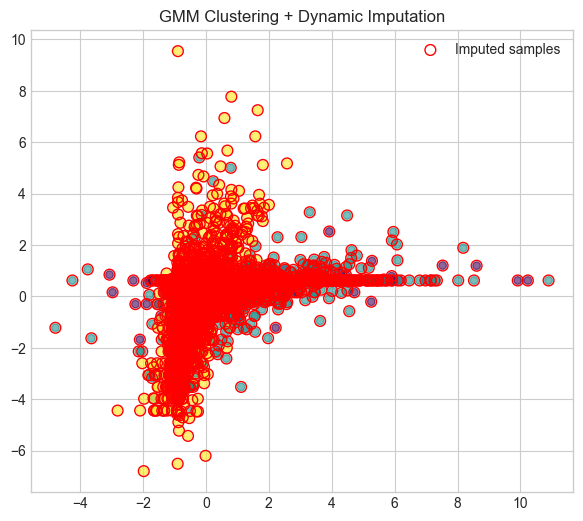

In [9]:
# Fit model
gmm_full = GMMMissing(n_components=3, max_iter=200, random_state=42)
gmm_full.fit_scale(X_incomplete)

print(f"Thuật toán hội tụ sau {gmm_full.n_iter_} vòng lặp.")

# Predict cluster
y_pred = gmm_full.predict(gmm_full.X_final_)


plt.figure(figsize=(7, 6))

plt.scatter(
    gmm_full.X_final_[:, 0], 
    gmm_full.X_final_[:, 1], 
    c=y_pred, cmap='viridis', s=30, alpha=0.6
)

# highlight các điểm từng bị missing
missing_rows_idx = np.where(mask_missing.any(axis=1))[0]
plt.scatter(
    gmm_full.X_final_[missing_rows_idx, 0],
    gmm_full.X_final_[missing_rows_idx, 1],
    facecolors='none', edgecolors='red', s=60,
    label='Imputed samples'
)

plt.title("GMM Clustering + Dynamic Imputation")
plt.legend()
plt.show()

In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(gmm_full.X_final_, y_pred)
print("Silhouette score:", score)

Silhouette score: 0.1489258071606693
